## Vacancy & Demand Risk Analysis
This notebook analyses the rental demand conditions across Melbourne using RTBAavtive rental bond data. Active bonds are used as a proxy for sustained rental demand and market tightness, complementing suburb-level rental yield and interest rate sensitivity analysis. 

## 1. Purpose 

While rental yields capture income potential and interest rate sensitivity reflects financing risks, neither directly measures the stability of rental demand. This notebook introduces demand-side indicators to assess how resilient rental income may be across different parts of Melbourne. 

## 2. Demand Data Considered 

Several potential sources of rental demand and vacancy information were evaluated for this project: 

- **SQM Research vacancy rates** provide suburb- and postcode-level vacancy estimates based on advertised rental listings. However, the underlying data are proprietary, not downloadable, which limits reproducibility. 
- **ABS rental indicators** provide high-quality national and state-level rental insights but generally too aggregated for comparative analysis within Melbourne.
- **RTBA (Residential Tenancies Bond Authority) data**, published via the Victorian Rental Report, provide comprehensive and regularly updated records of rental bond lodgements across Victoria. 

Given the objectives of this project and the need for reproducibile and publicly available data, RTBA active rental bond data were selected as the primary demand proxy. 

## 3. Selected Demand Proxy: Active Rental Bonds (Table 15 of Victorian Rental Report)

Active rental bonds represent the number of ongoing rental agreements with a lodged bond at a given point in time. As bonds are required for nearly all private rental agreements in Victoria, active bond counts provide a robust proxyfor the size and stability of the occupied rental market. 

Higher active bond counts indicates stronger and more sustained rental demand, while lower counts suggest a more volatile rental market. In this analysis, active bonds are used descriptively as a demand indicator rather than as a direct vacancy measure. 

In [25]:
import pandas as pd 

path = "../data/raw/rtba_active_bonds_lga_quarterly.csv"
bonds_raw = pd.read_csv(path)

bonds_raw.head()

,Table 15: Active bonds by Local Government Area,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Contents page,Unnamed: 9,...,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Jun 2010,Jun 2011,Jun 2012,Jun 2013,Jun 2014,Jun 2015,Jun 2016,Jun 2017,Jun 2018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Alpine,679,704,761,808,807,820,841,813,808,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ararat,530,594,640,722,711,709,736,716,767,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ballarat,"7,998","8,483","9,071","9,573","10,153","10,668","11,089","11,349","11,558",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
bonds_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 34 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Table 15: Active bonds by Local Government Area  80 non-null     object 
 1   Unnamed: 1                                       81 non-null     object 
 2   Unnamed: 2                                       81 non-null     object 
 3   Unnamed: 3                                       81 non-null     object 
 4   Unnamed: 4                                       81 non-null     object 
 5   Unnamed: 5                                       81 non-null     object 
 6   Unnamed: 6                                       81 non-null     object 
 7   Unnamed: 7                                       81 non-null     object 
 8   Contents page                                    81 non-null     object 
 9   Unnamed: 9                      

In [27]:
bonds_raw.columns

Index(['Table 15: Active bonds by Local Government Area', 'Unnamed: 1',
       'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6',
       'Unnamed: 7', 'Contents page', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18',
       'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22',
       'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26',
       'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30',
       'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33'],
      dtype='object')

## Cleaning of Table 15

In [29]:
#making row 1 the header 
bonds_raw.columns = bonds_raw.iloc[1]
bonds_raw.head()

1,NaN,Jun 2010,Jun 2011,Jun 2012,Jun 2013,Jun 2014,Jun 2015,Jun 2016,Jun 2017,Jun 2018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Jun 2010,Jun 2011,Jun 2012,Jun 2013,Jun 2014,Jun 2015,Jun 2016,Jun 2017,Jun 2018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Alpine,679,704,761,808,807,820,841,813,808,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ararat,530,594,640,722,711,709,736,716,767,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ballarat,"7,998","8,483","9,071","9,573","10,153","10,668","11,089","11,349","11,558",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
#removing rows 0 and 1
bonds_raw = bonds_raw.drop(index=[0,1])
bonds_raw.head()

1,NaN,Jun 2010,Jun 2011,Jun 2012,Jun 2013,Jun 2014,Jun 2015,Jun 2016,Jun 2017,Jun 2018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Alpine,679,704,761,808,807,820,841,813,808,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ararat,530,594,640,722,711,709,736,716,767,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ballarat,"7,998","8,483","9,071","9,573","10,153","10,668","11,089","11,349","11,558",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Banyule,"8,140","8,753","9,386","9,741","10,083","10,510","11,005","11,810","12,279",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Bass Coast,"2,596","3,077","2,812","2,601","2,818","2,884","2,960","3,015","2,953",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
#resetting index 
bonds_raw = bonds_raw.reset_index(drop=True)
bonds_raw.head()

1,NaN,Jun 2010,Jun 2011,Jun 2012,Jun 2013,Jun 2014,Jun 2015,Jun 2016,Jun 2017,Jun 2018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Alpine,679,704,761,808,807,820,841,813,808,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ararat,530,594,640,722,711,709,736,716,767,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ballarat,"7,998","8,483","9,071","9,573","10,153","10,668","11,089","11,349","11,558",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Banyule,"8,140","8,753","9,386","9,741","10,083","10,510","11,005","11,810","12,279",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Bass Coast,"2,596","3,077","2,812","2,601","2,818","2,884","2,960","3,015","2,953",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
#renaming lga column 
bonds_raw = bonds_raw.rename(
    columns = {bonds_raw.columns[0]: "lga"}
)
bonds_raw.head()

1,lga,Jun 2010,Jun 2011,Jun 2012,Jun 2013,Jun 2014,Jun 2015,Jun 2016,Jun 2017,Jun 2018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Alpine,679,704,761,808,807,820,841,813,808,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ararat,530,594,640,722,711,709,736,716,767,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ballarat,"7,998","8,483","9,071","9,573","10,153","10,668","11,089","11,349","11,558",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Banyule,"8,140","8,753","9,386","9,741","10,083","10,510","11,005","11,810","12,279",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Bass Coast,"2,596","3,077","2,812","2,601","2,818","2,884","2,960","3,015","2,953",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
#drop any empty columns
bonds_raw = bonds_raw.dropna(axis=1, how="all")
bonds_raw.head()

1,lga,Jun 2010,Jun 2011,Jun 2012,Jun 2013,Jun 2014,Jun 2015,Jun 2016,Jun 2017,Jun 2018,Jun 2019,Jun 2020,Jun 2021,Jun 2022,Jun 2023,Jun 2024,Jun 2025,1 year,5 year,Metro/RV
0,Alpine,679,704,761,808,807,820,841,813,808,830,829,853,865,844,848,851,0.4%,2.7%,R
1,Ararat,530,594,640,722,711,709,736,716,767,764,772,777,778,771,796,807,1.4%,4.5%,R
2,Ballarat,"7,998","8,483","9,071","9,573","10,153","10,668","11,089","11,349","11,558","11,798","12,303","12,881","13,091","13,419","13,634","13,917",2.1%,13.1%,R
3,Banyule,"8,140","8,753","9,386","9,741","10,083","10,510","11,005","11,810","12,279","12,766","12,975","12,807","13,186","13,607","13,487","13,092",-2.9%,0.9%,M
4,Bass Coast,"2,596","3,077","2,812","2,601","2,818","2,884","2,960","3,015","2,953","2,946","3,044","3,038","2,872","2,899","2,961","2,974",0.4%,-2.3%,R


In [41]:
#removing 1 and 5 year pct change columns 
bonds_raw = bonds_raw.drop(
    columns = ["1 year", "5 year"],
    errors = "ignore"
)
bonds_raw.head()

1,lga,Jun 2010,Jun 2011,Jun 2012,Jun 2013,Jun 2014,Jun 2015,Jun 2016,Jun 2017,Jun 2018,Jun 2019,Jun 2020,Jun 2021,Jun 2022,Jun 2023,Jun 2024,Jun 2025,Metro/RV
0,Alpine,679,704,761,808,807,820,841,813,808,830,829,853,865,844,848,851,R
1,Ararat,530,594,640,722,711,709,736,716,767,764,772,777,778,771,796,807,R
2,Ballarat,"7,998","8,483","9,071","9,573","10,153","10,668","11,089","11,349","11,558","11,798","12,303","12,881","13,091","13,419","13,634","13,917",R
3,Banyule,"8,140","8,753","9,386","9,741","10,083","10,510","11,005","11,810","12,279","12,766","12,975","12,807","13,186","13,607","13,487","13,092",M
4,Bass Coast,"2,596","3,077","2,812","2,601","2,818","2,884","2,960","3,015","2,953","2,946","3,044","3,038","2,872","2,899","2,961","2,974",R


In [ ]:
#identifying year columns 
year_cols = [c for c in bonds_raw.columns if str(c).startswith("Jun")]

#melt to long format 
bonds_long = bonds_raw.melt(
    id_vars="lga",
    value_vars=year_cols,
    var_name="year",
    value_name="active_bonds"
)


,lga,year,active_bonds
0,Alpine,Jun 2010,679
1,Ararat,Jun 2010,530
2,Ballarat,Jun 2010,"7,998"
3,Banyule,Jun 2010,"8,140"
4,Bass Coast,Jun 2010,"2,596"
...,...,...,...
2619,NaN,Jun 2025,NaN
2620,NaN,Jun 2025,NaN
2621,NaN,Jun 2025,NaN
2622,NaN,Jun 2025,NaN


In [47]:
bonds_long[bonds_long["year"]== "Jun 2025"]["active_bonds"].head(20)

2460       851
2461       807
2462    13,917
2463    13,092
2464     2,974
2465     3,447
2466     7,936
2467     1,147
2468    18,361
2469    16,084
2470       204
2471     2,031
2472     8,666
2473    26,283
2474       799
2475     1,334
2476       636
2477    19,175
2478     3,032
2479    12,803
Name: active_bonds, dtype: object

In [48]:
bonds_long.loc[bonds_long["year"] == "Jun 2025", "active_bonds"].notna().sum() 

np.int64(80)

In [49]:
bonds_long = bonds_long.dropna(subset=["lga","active_bonds"])

In [50]:
bonds_long

,lga,year,active_bonds
0,Alpine,Jun 2010,679
1,Ararat,Jun 2010,530
2,Ballarat,Jun 2010,"7,998"
3,Banyule,Jun 2010,"8,140"
4,Bass Coast,Jun 2010,"2,596"
...,...,...,...
2535,Wyndham,Jun 2025,"31,064"
2536,Yarra,Jun 2025,"18,168"
2537,Yarra Ranges,Jun 2025,"6,355"
2538,Yarriambiack,Jun 2025,200


In [51]:
#cleaning active_bonds (remove commas in values)
bonds_long["active_bonds"] = (
    bonds_long["active_bonds"]
    .astype(str)
    .str.replace(",","",regex=False)
)

bonds_long["active_bonds"] = pd.to_numeric(
    bonds_long["active_bonds"], errors="coerce"
)

bonds_long["active_bonds"].isna().sum()
bonds_long.head()

C:\Users\trabi\AppData\Local\Temp\ipykernel_41708\2773842373.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bonds_long["active_bonds"] = (
C:\Users\trabi\AppData\Local\Temp\ipykernel_41708\2773842373.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bonds_long["active_bonds"] = pd.to_numeric(


,lga,year,active_bonds
0,Alpine,Jun 2010,679
1,Ararat,Jun 2010,530
2,Ballarat,Jun 2010,7998
3,Banyule,Jun 2010,8140
4,Bass Coast,Jun 2010,2596


In [ ]:
#filtering to only June 2025
bonds_2025 = bonds_long[bonds_long["year"] == "Jun 2025"].copy()
bonds_2025.shape
bonds_2025.head() #this will be the final demand dataset used for the project

,lga,year,active_bonds
2460,Alpine,Jun 2025,851
2461,Ararat,Jun 2025,807
2462,Ballarat,Jun 2025,13917
2463,Banyule,Jun 2025,13092
2464,Bass Coast,Jun 2025,2974


In [58]:
df = pd.read_csv("../data/processed/suburb_house_rental_yield.csv")
df.columns
df.head()

,region,suburb,median_rent,property_type,median_price,sales_count,gross_yield,gross_yield_pct
0,Inner Melbourne,Armadale,1100.0,3 Bed House,2588000.0,20,0.022102,2.210201
1,Inner Melbourne,Carlton North,930.0,3 Bed House,1730000.0,20,0.027954,2.795376
2,Inner Melbourne,East Melbourne,1200.0,3 Bed House,1696000.0,2,0.036792,3.679245
3,Inner Melbourne,Elwood,1000.0,3 Bed House,2542500.0,20,0.020452,2.045231
4,Inner Melbourne,Fitzroy,1100.0,3 Bed House,1600000.0,24,0.035750,3.575000


In [60]:
#need to map suburbs to lga 
#using community dataset from Matthew Proctor's Australian Postcode Project

map_df = pd.read_csv("../data/raw/australian_postcodes.csv")
map_df.head()

,id,postcode,locality,state,long,lat,dc,type,status,sa3,...,altitude,chargezone,phn_code,phn_name,lgaregion,lgacode,electorate,electoraterating,sed_code,sed_name
0,230,200,ANU,ACT,149.11900,-35.277700,NaN,NaN,Updated 3-Dec-2022,NaN,...,NaN,N2,NaN,NaN,Unincorporated ACT,89399.0,Durack,NaN,NaN,NaN
1,21820,200,Australian National University,ACT,149.11890,-35.277700,NaN,NaN,Updated 3-Dec-2022,NaN,...,NaN,N2,NaN,NaN,Unincorporated ACT,89399.0,Durack,NaN,NaN,NaN
2,232,800,DARWIN,NT,130.83668,-12.458684,NaN,NaN,Updated 3-Dec-2022,70101.0,...,NaN,NT1,PHN701,Northern Territory,Darwin Waterfront Precinct,71150.0,Solomon,Inner Metropolitan,70022.0,Port Darwin
3,24049,800,DARWIN CITY,NT,130.83668,-12.458684,NaN,NaN,Updated 3-Dec-2022,70101.0,...,NaN,NT1,PHN701,Northern Territory,Darwin Waterfront Precinct,71150.0,Solomon,Inner Metropolitan,70022.0,Port Darwin
4,233,801,DARWIN,NT,130.83668,-12.458684,NaN,NaN,Updated 3-Dec-2022,70101.0,...,NaN,NT1,PHN701,NaN,Darwin,71000.0,Lingiari,Rural,NaN,NaN


In [68]:
#Filtering to only VIC
vic_map = map_df[map_df["state"] == "VIC"].copy()

#standardising suburb names
vic_map["suburb_std"] = (
    vic_map["locality"]
      .astype(str)
      .str.upper()
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
)


In [69]:
df = pd.read_csv("../data/processed/suburb_house_rental_yield.csv")

df["suburb_std"] = (
    df["suburb"]
      .astype(str)
      .str.upper()
      .str.strip()
      .str.replace(r"\s+", " ", regex=True)
)

In [71]:
vic_map[["locality", "postcode", "lgaregion"]].head(10)
vic_map["lgaregion"].isna().mean()

np.float64(0.006216445323537723)

In [72]:
suburb_to_lga = (
    vic_map.dropna(subset=["suburb_std", "lgaregion"])
      .groupby("suburb_std")["lgaregion"]
      .agg(lambda x: x.value_counts().index[0])   # most common LGA
      .reset_index()
      .rename(columns={"lgaregion": "lga"})
)

suburb_to_lga.head()

,suburb_std,lga
0,ABBEYARD,Wangaratta
1,ABBOTSFORD,Yarra
2,ABECKETT STREET,Melbourne
3,ABERFELDIE,Moonee Valley
4,ABERFELDY,Wellington


In [74]:
#merge lga into yield dataset
df_lga = df.merge(
    suburb_to_lga,
    on="suburb_std",
    how="left"
)

In [75]:
df_lga["lga"].notna().mean()
df_lga[df_lga["lga"].isna()][["suburb"]].head(30)

,suburb


In [76]:
yield_lga = (
    df_lga.dropna(subset=["lga"])
      .groupby("lga")
      .agg(
          avg_gross_yield_pct=("gross_yield_pct", "mean"),
          suburb_count=("suburb", "nunique")
      )
      .reset_index()
)

yield_lga.head()

,lga,avg_gross_yield_pct,suburb_count
0,Baw Baw,4.025806,1
1,Bayside (Vic.),2.343772,2
2,Boroondara,1.596056,3
3,Brimbank,3.576936,3
4,Campaspe,4.490501,1


In [77]:
yield_lga["lga"] = yield_lga["lga"].astype(str).str.upper().str.strip()
bonds_2025["lga"] = bonds_2025["lga"].astype(str).str.upper().str.strip()

In [78]:
demand_yield = yield_lga.merge(
    bonds_2025[["lga", "active_bonds"]],
    on="lga",
    how="inner"
)

demand_yield.shape
demand_yield.head()

,lga,avg_gross_yield_pct,suburb_count,active_bonds
0,BAW BAW,4.025806,1,3447
1,BOROONDARA,1.596056,3,18361
2,BRIMBANK,3.576936,3,16084
3,CAMPASPE,4.490501,1,2031
4,CARDINIA,4.074627,1,8666


In [79]:
df_lga["lga"].notna().mean()

np.float64(1.0)

In [80]:
yield_lga = (
    df_lga.groupby("lga")
      .agg(
          avg_gross_yield_pct=("gross_yield_pct", "mean"),
          suburb_count=("suburb", "nunique")
      )
      .reset_index()
)

yield_lga.head()

,lga,avg_gross_yield_pct,suburb_count
0,Baw Baw,4.025806,1
1,Bayside (Vic.),2.343772,2
2,Boroondara,1.596056,3
3,Brimbank,3.576936,3
4,Campaspe,4.490501,1


In [81]:
yield_lga.sort_values("suburb_count", ascending=False).head(10)
yield_lga["avg_gross_yield_pct"].describe()

count    44.000000
mean      3.705181
std       1.041694
min       1.596056
25%       2.906592
50%       3.575968
75%       4.493243
max       5.925926
Name: avg_gross_yield_pct, dtype: float64

In [82]:
yield_lga["lga"] = yield_lga["lga"].astype(str).str.upper().str.strip()
bonds_2025["lga"] = bonds_2025["lga"].astype(str).str.upper().str.strip()

In [83]:
demand_yield = yield_lga.merge(
    bonds_2025[["lga", "active_bonds"]],
    on="lga",
    how="inner"
)

demand_yield.shape
demand_yield.head()

,lga,avg_gross_yield_pct,suburb_count,active_bonds
0,BAW BAW,4.025806,1,3447
1,BOROONDARA,1.596056,3,18361
2,BRIMBANK,3.576936,3,16084
3,CAMPASPE,4.490501,1,2031
4,CARDINIA,4.074627,1,8666


In [84]:
len(yield_lga), len(bonds_2025), len(demand_yield)

(44, 80, 41)

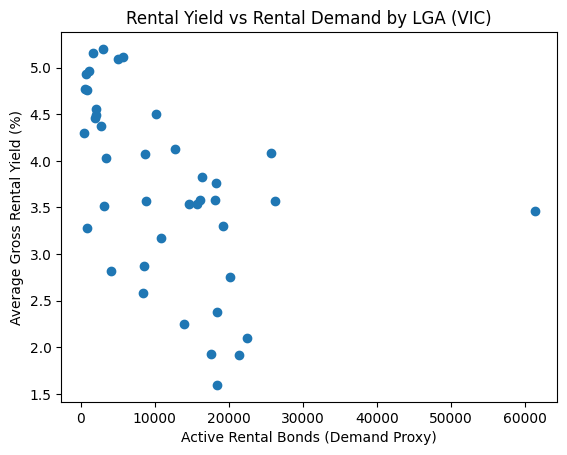

,active_bonds,avg_gross_yield_pct
active_bonds,1.000000,-0.467344
avg_gross_yield_pct,-0.467344,1.000000


In [86]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(demand_yield["active_bonds"], demand_yield["avg_gross_yield_pct"])
plt.xlabel("Active Rental Bonds (Demand Proxy)")
plt.ylabel("Average Gross Rental Yield (%)")
plt.title("Rental Yield vs Rental Demand by LGA (VIC)")
plt.show()
demand_yield[["active_bonds", "avg_gross_yield_pct"]].corr()

In [87]:
demand_yield["demand_band"] = pd.qcut(
    demand_yield["active_bonds"],
    q=3,
    labels=["Low Demand", "Medium Demand", "High Demand"]
)

band_summary = demand_yield.groupby("demand_band").agg(
    avg_yield_pct=("avg_gross_yield_pct", "mean"),
    avg_active_bonds=("active_bonds", "mean"),
    lga_count=("lga", "nunique")
).reset_index()

band_summary

C:\Users\trabi\AppData\Local\Temp\ipykernel_41708\1434758780.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  band_summary = demand_yield.groupby("demand_band").agg(


,demand_band,avg_yield_pct,avg_active_bonds,lga_count
0,Low Demand,4.483657,1759.000000,14
1,Medium Demand,3.633669,9801.692308,13
2,High Demand,2.988001,22857.142857,14


In [88]:
demand_yield.to_csv("../data/processed/yield_demand_lga_2025.csv", index=False)
band_summary.to_csv("../data/processed/yield_demand_band_summary.csv", index=False)